In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Connect to (or create) the SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
#  Create a sample 'sales' table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [4]:
#Insert sample data (if table is empty)
cursor.execute("SELECT COUNT(*) FROM sales")
if cursor.fetchone()[0] == 0:
    sample_data = [
        ("Laptop", 5, 700),
        ("Laptop", 3, 700),
        ("Mouse", 10, 25),
        ("Mouse", 5, 25),
        ("Keyboard", 7, 50),
        ("Monitor", 4, 150),
        ("Monitor", 3, 150),
    ]
    cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
    conn.commit()


In [5]:
# Query total quantity and revenue by product
query = """
SELECT 
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM 
    sales
GROUP BY 
    product
"""
df = pd.read_sql_query(query, conn)

In [6]:
# Display the summary
print("📊 Sales Summary:")
print(df)

📊 Sales Summary:
    product  total_qty  revenue
0  Keyboard          7    350.0
1    Laptop          8   5600.0
2   Monitor          7   1050.0
3     Mouse         15    375.0


<Figure size 800x500 with 0 Axes>

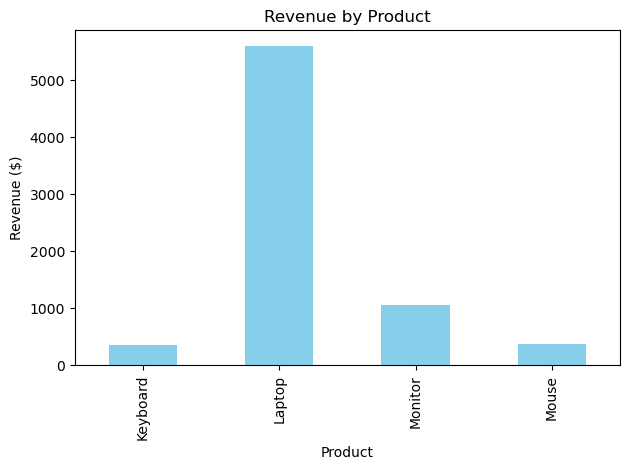

In [7]:
#Plot a bar chart for revenue
plt.figure(figsize=(8, 5))
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()

In [8]:
# Optional: Save the chart
plt.savefig("sales_chart.png")
plt.show()

# Close the connection
conn.close()

<Figure size 640x480 with 0 Axes>